## **Кластеризация данных о физической активности**

In [1]:
#Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import AgglomerativeClustering

### Шаг 1. Анализ данных

In [2]:
# Считываем и анализируем датасет
df = pd.read_csv('Physical_Activity_Monitoring_unlabeled.csv')
df.head()

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


#### Датасет содержит по 54 столбца на строку, столбцы содержат следующие данные:

1 временная метка (с)

2 частота сердечных сокращений (уд/мин)

3-19 данные с датчиков на руке

20-36 данные с датчиков на груди

37-53 данные с датчиков на лодыжке

#### Сенсорные данные IMU содержат следующие столбцы:

1 температура (°C)

2-4 Данные 3D-ускорения (мс-2), масштаб: ±16g, разрешение: 13 бит

5-7 Данные 3D-ускорения (мс-2), масштаб: ±6g, разрешение: 13 бит*

8-10 данных 3D-гироскопа (рад/с)

11-13 Данные 3D-магнитометра (мкТл)

In [3]:
# Рассмотрим пропуски и типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  ha

In [4]:
#Размер таблицы
df.shape

(534601, 53)

In [5]:
df_nan = df.loc[:, df.isnull().any()]
# посмотрим процент пропущенных значений
df_nan.isnull().sum() / len(df_nan) * 100

handTemperature      0.755891
handAcc16_1          0.755891
handAcc16_2          0.755891
handAcc16_3          0.755891
handAcc6_1           0.755891
handAcc6_2           0.755891
handAcc6_3           0.755891
handGyro1            0.755891
handGyro2            0.755891
handGyro3            0.755891
handMagne1           0.755891
handMagne2           0.755891
handMagne3           0.755891
handOrientation1     0.755891
handOrientation2     0.755891
handOrientation3     0.755891
handOrientation4     0.755891
chestTemperature     0.151328
chestAcc16_1         0.151328
chestAcc16_2         0.151328
chestAcc16_3         0.151328
chestAcc6_1          0.151328
chestAcc6_2          0.151328
chestAcc6_3          0.151328
chestGyro1           0.151328
chestGyro2           0.151328
chestGyro3           0.151328
chestMagne1          0.151328
chestMagne2          0.151328
chestMagne3          0.151328
chestOrientation1    0.151328
chestOrientation2    0.151328
chestOrientation3    0.151328
chestOrien

Пропуски имеются, но менее 1% в каждом признаке

In [6]:
df.describe()

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
count,534601.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,...,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,534601.000000
mean,1593.538159,32.451221,-4.435286,3.241949,4.079375,-4.375896,3.218250,4.262513,-0.008852,0.028801,...,-0.031911,0.002304,-28.756284,2.115624,14.723345,0.360159,-0.091093,0.303517,-0.173845,4.558615
std,1243.906483,1.754847,7.062004,7.224031,3.831257,7.068961,6.864782,3.822053,1.160112,0.926832,...,0.618840,2.036102,19.303887,22.253170,17.907491,0.301254,0.559400,0.344271,0.466304,2.318076
min,37.660000,27.500000,-114.755000,-82.550900,-73.949700,-61.214700,-61.824200,-61.577100,-19.690500,-7.609010,...,-7.701040,-14.019600,-172.865000,-136.951000,-102.716000,0.000003,-0.954848,-0.876838,-0.997040,1.000000
25%,475.500000,31.312500,-9.076360,0.682775,1.588777,-8.981072,0.687587,1.780160,-0.153182,-0.083315,...,-0.049003,-0.221911,-39.689950,-10.960850,2.252230,0.145023,-0.676392,0.006839,-0.580040,2.000000
50%,827.610000,32.875000,-5.465610,3.089205,4.157125,-5.434845,3.127145,4.413625,-0.004439,0.004013,...,-0.004481,0.000354,-26.285600,-0.014372,16.599500,0.240996,0.000000,0.322698,-0.281681,5.000000
75%,2876.990000,33.812500,0.383679,5.559742,6.864212,0.424770,5.592180,7.148178,0.130310,0.094342,...,0.048972,0.032649,-14.549500,19.245900,25.947100,0.501671,0.410052,0.594198,0.252247,7.000000
max,4007.730000,35.250000,60.912600,155.532000,78.480100,34.159400,62.259800,60.843700,22.960000,11.862600,...,6.002540,14.482700,41.764800,92.867000,122.521000,1.000000,0.959538,0.920506,0.996105,8.000000


Признаки различаются по масштабу

In [7]:
# Проверка на дубликаты
df.duplicated().sum()

np.int64(0)

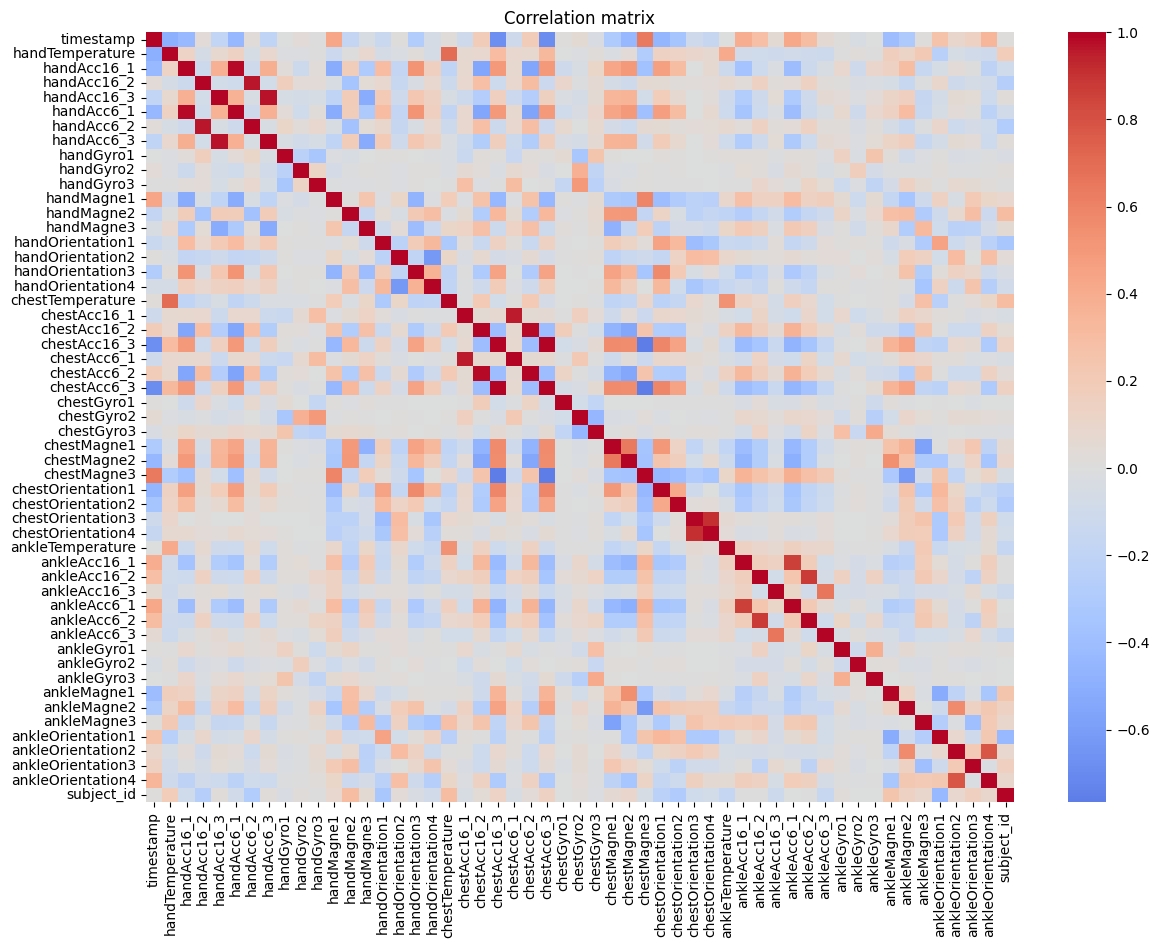

In [8]:
# Построим матрицу корреляций
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

Из-за высокого числа признаков, значения корреляций не отображены, но по цветам видно, что данные с датчиков handAcc16_n и handAcc6_n (где n = 1,2,3) попарно имеют высокую корреляцию между собой. Аналогично: chest_Acc16_n с chest_Acc6_n и ankle_Acc16_n с ankle_Acc6_n.

Вывод по анализу данных:

1) Датасет содержит пропуски
2) Дубликаты отсутствуют
3) Необходимо масштабировать признаки
4) Некоторые признаки сильно коррелируют между собой

### Шаг 2. Предобработка данных

#### Шаг 2.1 Удаление признаков


Т.к. наша задача - разделить активности по данныс с датчиков, то удаляем признаки subject_id и timestamp, которые не относятся к показаниям датчиков.

In [9]:
df = df.drop(columns=['timestamp', 'subject_id'])

#### Шаг 2.2 Обработка пропусков

Заменим во всех признаках пропущенные значения медианой.

In [10]:
df = df.fillna(df.median())
df.isna().sum().sum()

np.int64(0)

#### Шаг 2.3 Снижение размерности

Заменим отдельные показания по акселерометру, гироскопу и магнитометру нормами.

In [11]:
def norm(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

df['handAcc16_norm'] = norm(df['handAcc16_1'], df['handAcc16_2'], df['handAcc16_3'])
df['handAcc6_norm'] = norm(df['handAcc6_1'], df['handAcc6_2'], df['handAcc6_3'])
df['chestAcc16_norm'] = norm(df['chestAcc16_1'], df['chestAcc16_2'], df['chestAcc16_3'])
df['chestAcc6_norm'] = norm(df['chestAcc6_1'], df['chestAcc6_2'], df['chestAcc6_3'])
df['ankleAcc16_norm'] = norm(df['ankleAcc16_1'], df['ankleAcc16_2'], df['ankleAcc16_3'])
df['ankleAcc6_norm'] = norm(df['ankleAcc6_1'], df['ankleAcc6_2'], df['ankleAcc6_3'])
df['handGyro_norm'] = norm(df['handGyro1'], df['handGyro2'], df['handGyro3'])
df['handMagne_norm'] = norm(df['handMagne1'], df['handMagne2'], df['handMagne3'])
df['chestGyro_norm'] = norm(df['chestGyro1'], df['chestGyro2'], df['chestGyro3'])
df['chestMagne_norm'] = norm(df['chestMagne1'], df['chestMagne2'], df['chestMagne3'])
df['ankleGyro_norm'] = norm(df['ankleGyro1'], df['ankleGyro2'], df['ankleGyro3'])
df['ankleMagne_norm'] = norm(df['ankleMagne1'], df['ankleMagne2'], df['ankleMagne3'])

#Удаляем
df = df.drop(columns=[
    'handAcc16_1','handAcc16_2','handAcc16_3',
    'handAcc6_1','handAcc6_2','handAcc6_3',
    'chestAcc16_1','chestAcc16_2','chestAcc16_3',
    'chestAcc6_1','chestAcc6_2','chestAcc6_3',
    'ankleAcc16_1','ankleAcc16_2','ankleAcc16_3',
    'ankleAcc6_1','ankleAcc6_2','ankleAcc6_3',
    'handGyro1','handGyro2','handGyro3',
    'handMagne1','handMagne2','handMagne3',
    'chestGyro1','chestGyro2','chestGyro3',
    'chestMagne1','chestMagne2','chestMagne3',
    'ankleGyro1','ankleGyro2','ankleGyro3',
    'ankleMagne1','ankleMagne2','ankleMagne3'
])

Сделаем аналогично для норм из 4 компонент:

In [12]:
def norm4(a, b, c, d):
    return np.sqrt(a**2 + b**2 + c**2 + d**2)

df['handOrientation_norm'] = norm4(
    df['handOrientation1'],
    df['handOrientation2'],
    df['handOrientation3'],
    df['handOrientation4']
)

df['chestOrientation_norm'] = norm4(
    df['chestOrientation1'],
    df['chestOrientation2'],
    df['chestOrientation3'],
    df['chestOrientation4']
)

df['ankleOrientation_norm'] = norm4(
    df['ankleOrientation1'],
    df['ankleOrientation2'],
    df['ankleOrientation3'],
    df['ankleOrientation4']
)

df = df.drop(columns=[
    'handOrientation1','handOrientation2','handOrientation3','handOrientation4',
    'chestOrientation1','chestOrientation2','chestOrientation3','chestOrientation4',
    'ankleOrientation1','ankleOrientation2','ankleOrientation3','ankleOrientation4'
])

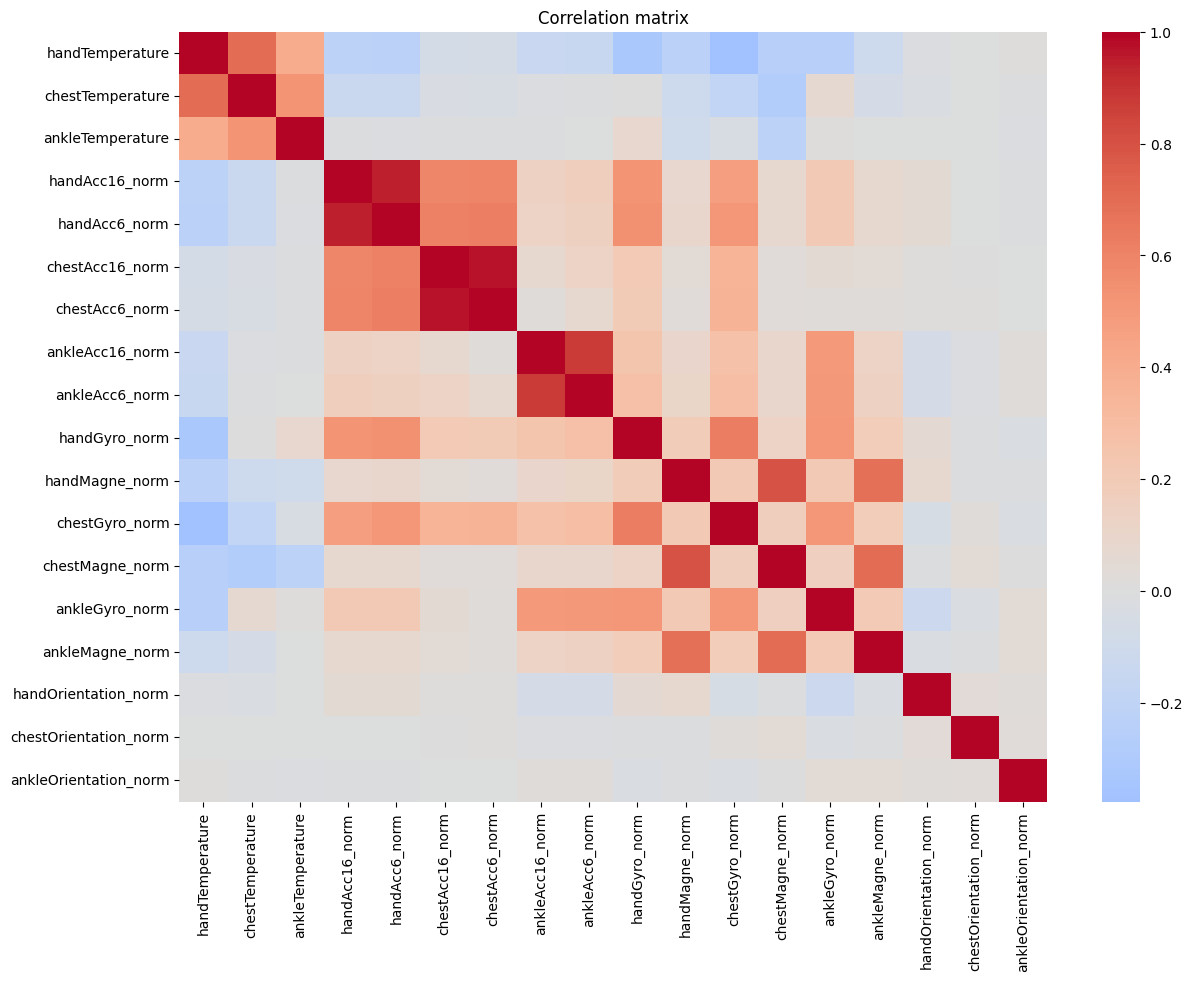

In [13]:
# Посмотрим еще раз на матрицу корреляций
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

Некоторые признаки, например handAcc16_norm и handAcc6_norm сильно коррелируют между собой. Объединим такие признаки

In [14]:
df['handAcc_norm'] = (df['handAcc16_norm'] + df['handAcc6_norm']) / 2
df['chestAcc_norm'] = (df['chestAcc16_norm'] + df['chestAcc6_norm']) / 2
df['ankleAcc_norm'] = (df['ankleAcc16_norm'] + df['ankleAcc6_norm']) / 2

df = df.drop(columns=[
    'handAcc16_norm','handAcc6_norm',
    'chestAcc16_norm','chestAcc6_norm',
    'ankleAcc16_norm','ankleAcc6_norm'
])


#### Шаг 2.4 Масштабирование признаков

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

X_scaled.describe().loc[['mean', 'std']]

,handTemperature,chestTemperature,ankleTemperature,handGyro_norm,handMagne_norm,chestGyro_norm,chestMagne_norm,ankleGyro_norm,ankleMagne_norm,handOrientation_norm,chestOrientation_norm,ankleOrientation_norm,handAcc_norm,chestAcc_norm,ankleAcc_norm
mean,-1.353431e-16,5.638344e-16,-2.646913e-15,-8.417909e-17,-3.798592e-16,2.115941e-17,2.858912e-16,4.851246e-18,-1.269697e-16,1.480109e-15,-1.520062e-14,8.745109e-15,-1.944153e-16,3.602748e-16,4.232546e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00


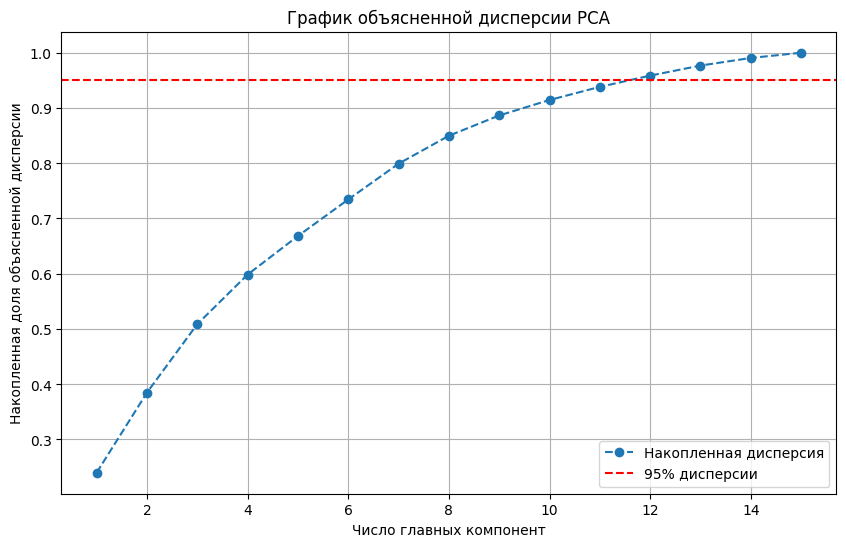

In [16]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker='o',
    linestyle='--',
    label='Накопленная дисперсия'
)

plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')

plt.xlabel('Число главных компонент')
plt.ylabel('Накопленная доля объясненной дисперсии')
plt.title('График объясненной дисперсии PCA')
plt.legend()
plt.grid()
plt.show()

In [17]:
pca = PCA(n_components=0.95, random_state=42)  # Оставляем компоненты, которые объясняют 95% дисперсии
X_pca = pca.fit_transform(X_scaled)

print("Число выбранных компонент:", pca.n_components_)

Число выбранных компонент: 12


После предобработки данных (нормирование и объединение признаков), стандартизации и применения PCA было выбрано 12 компонентов, которые объясняют 95% дисперсии исходных данных.

### Шаг 3. Определение числа кластеров для KMeans

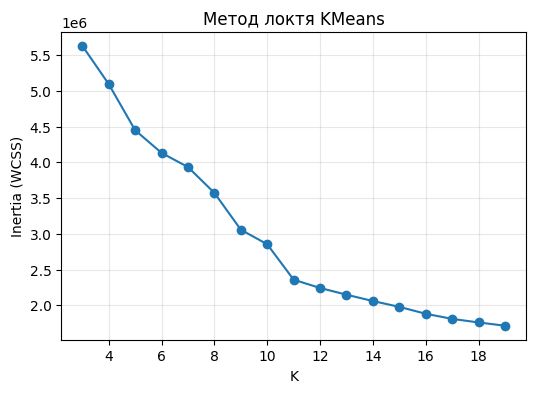

K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Inertias: [5631414.268827212, 5094911.869970651, 4449702.503168112, 4131707.340339398, 3934032.0238134894, 3572402.7638027184, 3057748.226417075, 2853602.991010351, 2357996.529143821, 2242365.118793713, 2148134.864382909, 2059757.6946625083, 1977969.3305756673, 1881502.8202996342, 1809865.4880326935, 1759833.1271527181, 1714262.564501198]


In [18]:
#подбор числа кластеров K
#метод локтя
inertias = []
K_values = list(range(3, 20))

for k in K_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_values, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia (WCSS)")
plt.title("Метод локтя KMeans")
plt.grid(alpha=0.3)
plt.show()

print("K values:", K_values)
print("Inertias:", inertias)

Метод локтя не дает точный ответ, сколько кластеров выбрать. Можно выделить перегиб около K = 9-11

График silhouette score (для ускорения расчета используем sample_size=10000):

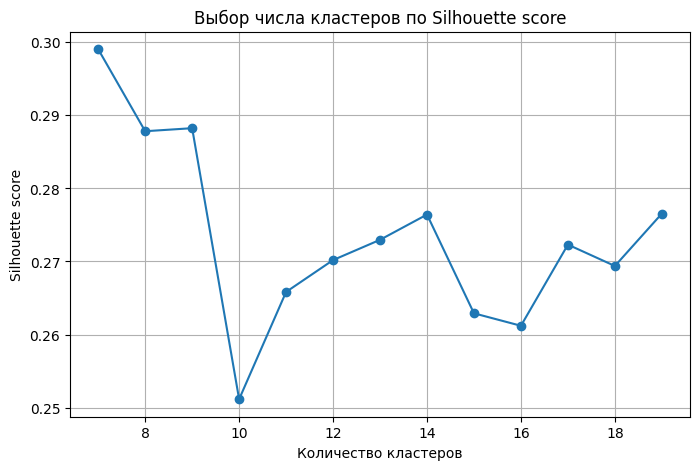

In [19]:
MAX_SAMPLES = 10000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

if X_pca.shape[0] > MAX_SAMPLES:
    sample_idx = rng.choice(X_pca.shape[0], size=MAX_SAMPLES, replace=False)
    X_sil = X_pca[sample_idx]
else:
    X_sil = X_pca

k_values = range(7, 20)
silhouette_scores = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sil)
    score = silhouette_score(X_sil, labels)

    silhouette_scores[k] = score

plt.figure(figsize=(8, 5))
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o'
)

plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette score')
plt.title('Выбор числа кластеров по Silhouette score')
plt.grid()
plt.show()

Опытным путем было выявлено, что при sample_size=10000 и sample_size=50000 результаты идентичны, поэтому Silhouette score для быстроты считался при sample_size=10000. Его значение растет при увеличении количества кластеров, но если брать большое количество кластеров, результаты будет трудно интерпретировать, т.к. сложнее выделить активности. Рассмотрим внимательнее силуэты при количестве кластеров от 11 до 14:

For n_clusters = 11, average silhouette_score = 0.2658


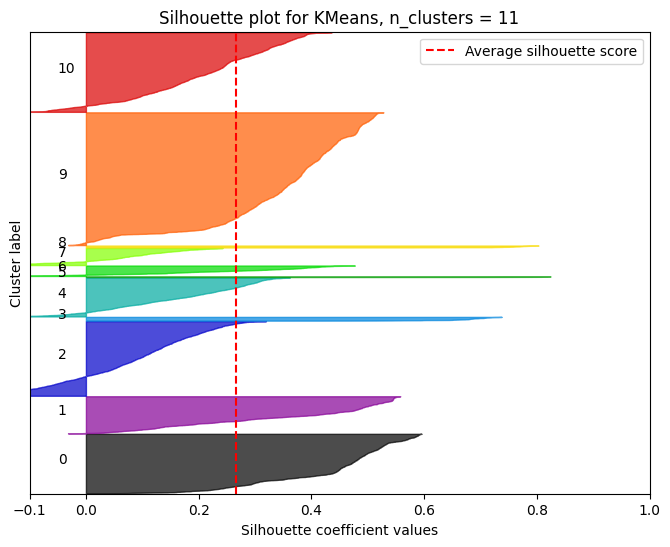

For n_clusters = 12, average silhouette_score = 0.2702


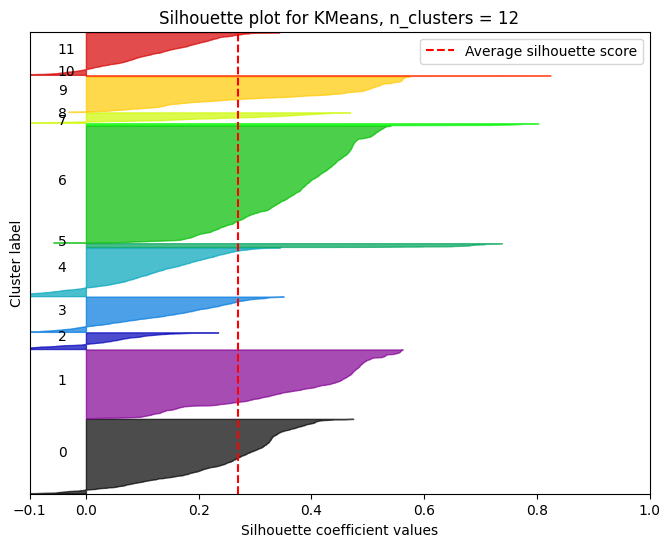

For n_clusters = 13, average silhouette_score = 0.2730


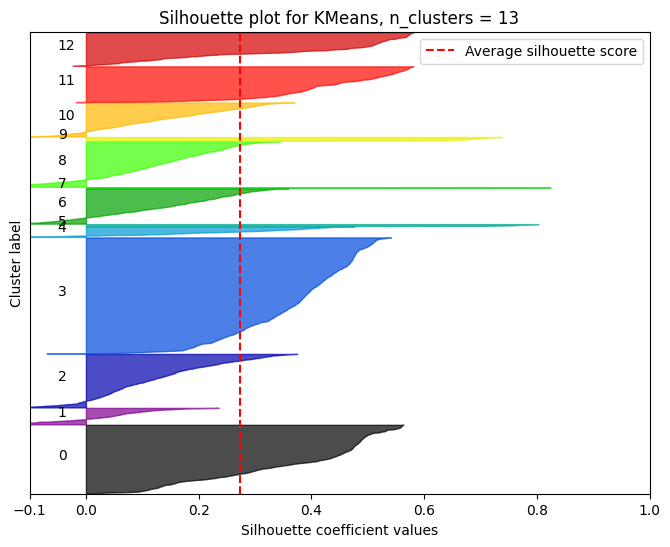

For n_clusters = 14, average silhouette_score = 0.2764


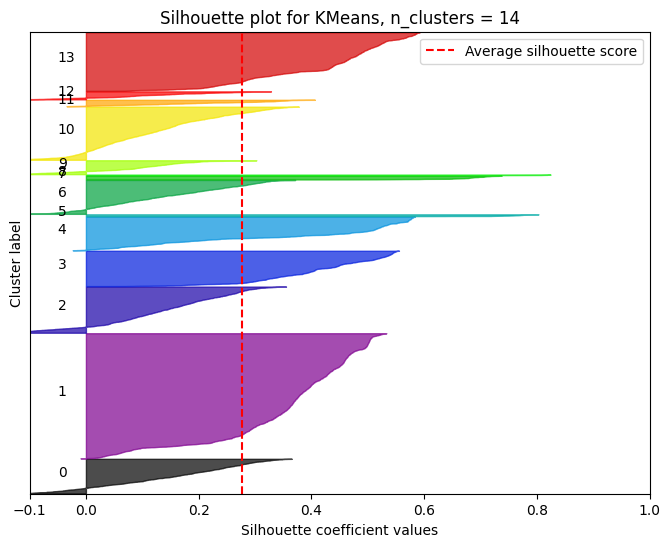

In [20]:
range_n_clusters = range(11, 15)

for n_clusters in range_n_clusters:
    fig, ax1 = plt.subplots(figsize=(8, 6))

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, X_sil.shape[0] + (n_clusters + 1) * 10])

    clusterer = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=10
    )

    cluster_labels = clusterer.fit_predict(X_sil)

    silhouette_avg = silhouette_score(X_sil, cluster_labels)
    print(
        f'For n_clusters = {n_clusters}, '
        f'average silhouette_score = {silhouette_avg:.4f}'
    )

    sample_silhouette_values = silhouette_samples(X_sil, cluster_labels)

    y_lower = 10

    for i in range(n_clusters):
        values = sample_silhouette_values[cluster_labels == i]
        values.sort()

        size_cluster_i = values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    ax1.axvline(
        x=silhouette_avg,
        color='red',
        linestyle='--',
        label='Average silhouette score'
    )

    ax1.set_title(f'Silhouette plot for KMeans, n_clusters = {n_clusters}')
    ax1.set_xlabel('Silhouette coefficient values')
    ax1.set_ylabel('Cluster label')
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    ax1.legend()
    plt.show()

Анализ silhouette score показал максимум при K = 14,однако при K = 14 появилось несколько маленьких кластеров. В качестве компромиссного значения выбрано К = 12.

### Шаг 3. Обучение KMeans

In [21]:
best_k = 12

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

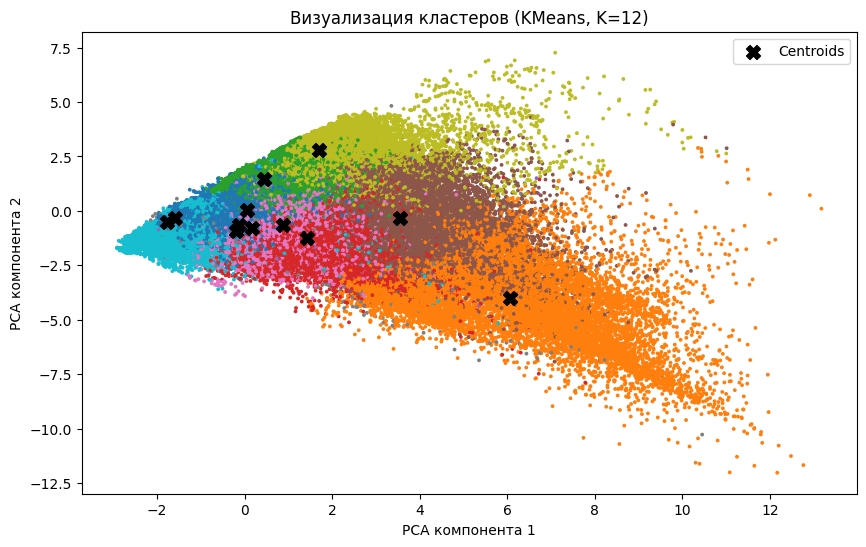

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='tab10',
    s=3
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='black',
    s=100,
    marker='X',
    label='Centroids'
)

plt.xlabel('PCA компонента 1')
plt.ylabel('PCA компонента 2')
plt.title('Визуализация кластеров (KMeans, K=12)')
plt.legend()

plt.show()

### Шаг 4. Сравнение с другими моделями

#### DBSCAN

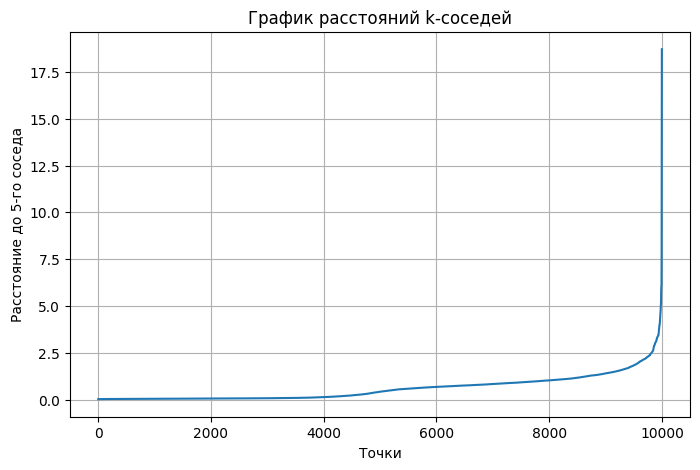

In [23]:
from sklearn.neighbors import NearestNeighbors

rng = np.random.default_rng(RANDOM_STATE)

if X_pca.shape[0] > MAX_SAMPLES:
    sample_idx = rng.choice(X_pca.shape[0], size=MAX_SAMPLES, replace=False)
    X_db = X_pca[sample_idx]
else:
    X_db = X_pca

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_db)

distances, indices = neighbors_fit.kneighbors(X_db)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))
plt.plot(distances)

plt.title("График расстояний k-соседей")
plt.xlabel("Точки")
plt.ylabel("Расстояние до 5-го соседа")

plt.grid()
plt.show()

По графику можно предположить, что оптимальный eps находится в диапазоне 1.5 - 2.5

eps=1.5
clusters=23
noise points=563
-----------


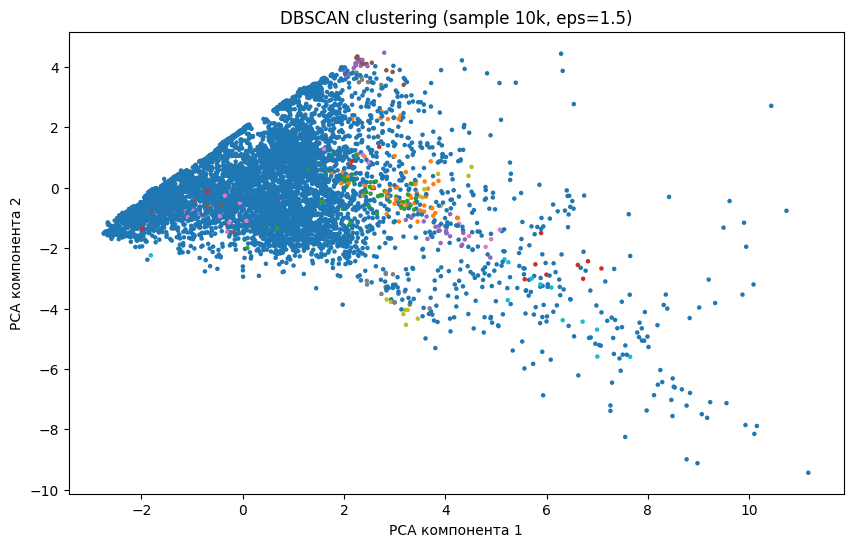

eps=1.7
clusters=18
noise points=401
-----------


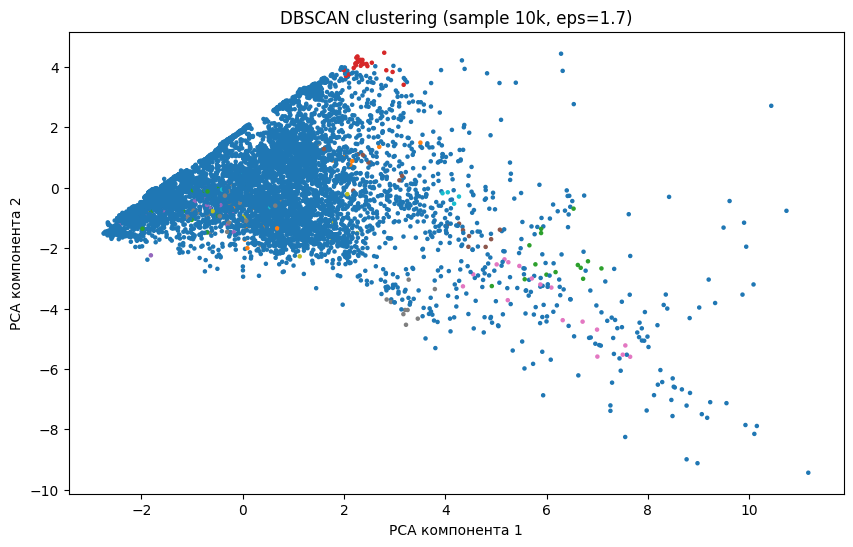

eps=2.0
clusters=15
noise points=255
-----------


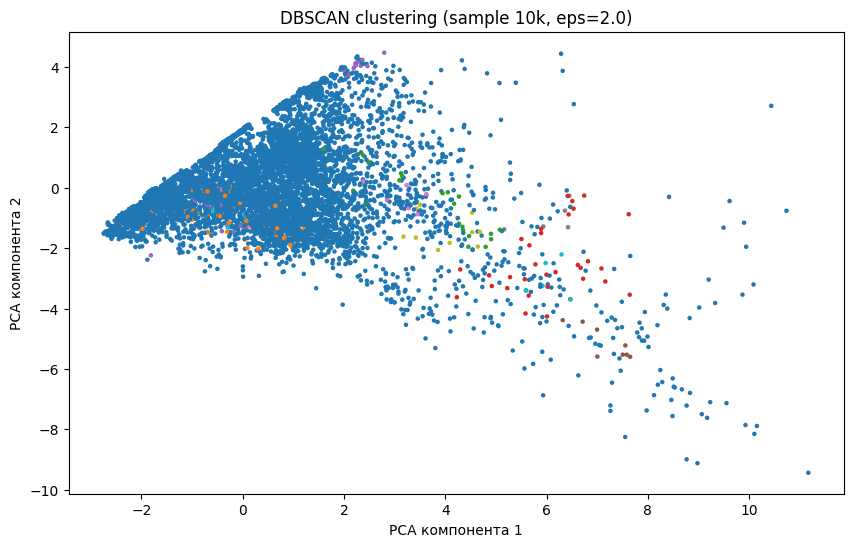

eps=2.2
clusters=14
noise points=174
-----------


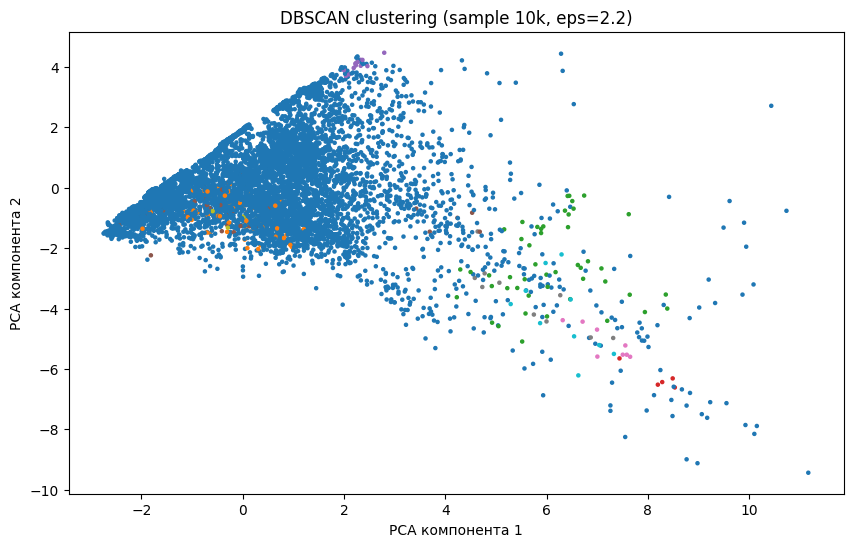

eps=2.5
clusters=6
noise points=120
-----------


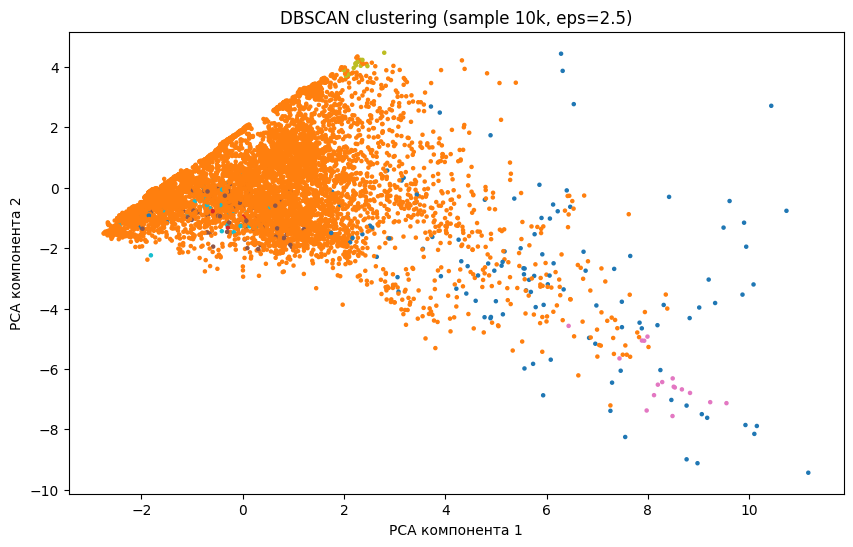

In [24]:
from sklearn.cluster import DBSCAN

eps_values = [1.5, 1.7, 2.0, 2.2, 2.5]

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        n_jobs=-1
    )

    db_clusters = dbscan.fit_predict(X_db)

    n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
    noise = list(db_clusters).count(-1)

    print(f"eps={eps}")
    print(f"clusters={n_clusters}")
    print(f"noise points={noise}")
    print("-----------")

    plt.figure(figsize=(10,6))

    plt.scatter(
        X_db[:,0],
        X_db[:,1],
        c=db_clusters,
        cmap='tab10',
        s=5
    )

    plt.title(f"DBSCAN clustering (sample 10k, eps={eps})")
    plt.xlabel("PCA компонента 1")
    plt.ylabel("PCA компонента 2")

    plt.show()

По визуализации видно, что при при увеличении eps количество кластеров уменьшается, а точки объединяются в более крупные кластеры. Kmeans в нашем случае оказался лучше, т.к. более наглядно разделяет активности на кластеры.Это позволит лучше интерпретировать результат.

#### AgglomerativeClustering

In [25]:
# Подбор K

rng = np.random.default_rng(RANDOM_STATE)

if X_pca.shape[0] > MAX_SAMPLES:
    sample_idx = rng.choice(X_pca.shape[0], size=MAX_SAMPLES, replace=False)
    X_aggl = X_pca[sample_idx]
else:
    X_aggl = X_pca

agg_results = []

for k in range(7, 15):
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = agg.fit_predict(X_aggl)

    score = silhouette_score(X_aggl, labels)

    agg_results.append({
        'n_clusters': k,
        'silhouette_score': score
    })

    print(f"K = {k}, silhouette = {score:.4f}")

agg_results = pd.DataFrame(agg_results)
agg_results

K = 7, silhouette = 0.2809
K = 8, silhouette = 0.2847
K = 9, silhouette = 0.2930
K = 10, silhouette = 0.2240
K = 11, silhouette = 0.2331
K = 12, silhouette = 0.2388
K = 13, silhouette = 0.2406
K = 14, silhouette = 0.2365


,n_clusters,silhouette_score
0,7,0.280893
1,8,0.284703
2,9,0.292952
3,10,0.223953
4,11,0.233083
5,12,0.238846
6,13,0.240598
7,14,0.236541


Наилучшее количество кластеров для AgglomerativeClustering - 9. silhouette_score = 0.293. 

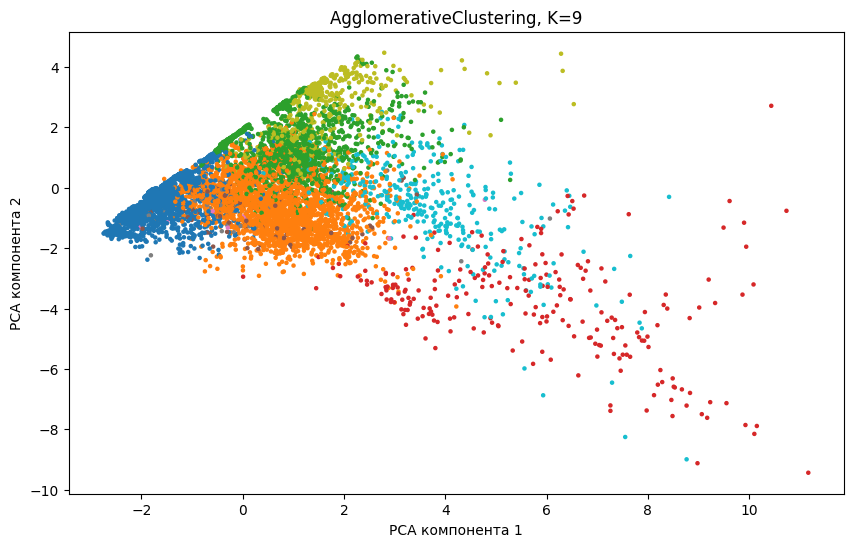

In [26]:
# Визуализация кластеров
agg = AgglomerativeClustering(
    n_clusters=9,
    linkage='ward'
)

agg_labels = agg.fit_predict(X_aggl)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_aggl[:, 0],
    X_aggl[:, 1],
    c=agg_labels,
    cmap='tab10',
    s=5
)
plt.xlabel('PCA компонента 1')
plt.ylabel('PCA компонента 2')
plt.title(f'AgglomerativeClustering, K={9}')
plt.show()


Для итогового результата выбрана модель KMeans, количество кластеров - 12. AgglomerativeClustering требует слишком больших вычислительных мощностей для обучения на полном объеме данных. Сохраним результат:

In [33]:
from sklearn.cluster import KMeans
import pandas as pd

clusterer = KMeans(
    n_clusters=12,
    random_state=42,
    n_init="auto"
)

cluster_labels = clusterer.fit_predict(X_pca)

activity_ids = pd.factorize(cluster_labels)[0] + 1

submission = pd.DataFrame({
    "Index": range(len(activity_ids)),
    "activityID": activity_ids
})

submission.to_csv("submission_kmeans_12.csv", index=False)

submission.head()

,Index,activityID
0,0,1
1,1,2
2,2,1
3,3,3
4,4,1


Вывод по работе: В ходе практической работы был проанализирован и предобработан датасет с данными об активностях пользователей. С целью снижения размерности и удаления шума, часть признаков была преобразована нормированием и объединением. Преобразованные данные были кластеризированы моделями KMeans, DBSCAN и AgglomerativeClustering. Оптимальной моделью была выбрана KMeans с количеством кластеров - 12 - она лучше интерпретируется по сравнению с DBSCAN и не требует большой вычислительной мощности по сравнению с AgglomerativeClustering.

Скриншот с Kaggle

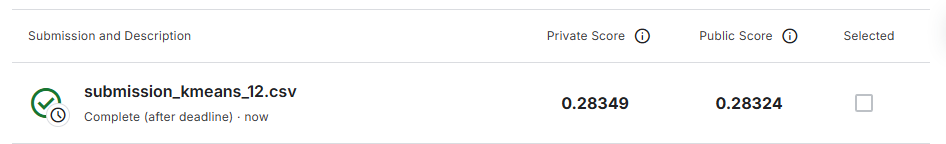